In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding = "latin-1")
print(df.shape)
print(df.columns.tolist())

(180519, 53)
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping d

In [3]:
for col in df.columns:
    print(col)

Type
Days for shipping (real)
Days for shipment (scheduled)
Benefit per order
Sales per customer
Delivery Status
Late_delivery_risk
Category Id
Category Name
Customer City
Customer Country
Customer Email
Customer Fname
Customer Id
Customer Lname
Customer Password
Customer Segment
Customer State
Customer Street
Customer Zipcode
Department Id
Department Name
Latitude
Longitude
Market
Order City
Order Country
Order Customer Id
order date (DateOrders)
Order Id
Order Item Cardprod Id
Order Item Discount
Order Item Discount Rate
Order Item Id
Order Item Product Price
Order Item Profit Ratio
Order Item Quantity
Sales
Order Item Total
Order Profit Per Order
Order Region
Order State
Order Status
Order Zipcode
Product Card Id
Product Category Id
Product Description
Product Image
Product Name
Product Price
Product Status
shipping date (DateOrders)
Shipping Mode


In [4]:
print(df.isnull().sum())


Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [5]:
print(df.duplicated().sum())

0


In [6]:
cols_to_drop = [
    'Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname',
    'Customer Street', 'Product Description', 'Product Image', 
    'Product Status', 'Order Zipcode'
]
df = df.drop(columns = cols_to_drop)
print(df.shape)

(180519, 44)


In [7]:
df['delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
print(df['delay'].describe())

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: delay, dtype: float64


In [8]:
print(df.groupby("Shipping Mode")["delay"].mean().sort_values(ascending=False))

Shipping Mode
Second Class      1.990828
First Class       1.000000
Same Day          0.478279
Standard Class   -0.004093
Name: delay, dtype: float64


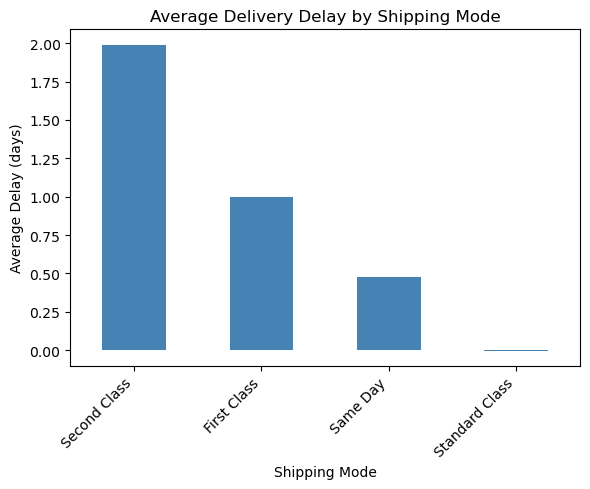

In [28]:
import matplotlib.pyplot as plt

delay_by_mode = df.groupby('Shipping Mode')['delay'].mean().sort_values(ascending=False)
delay_by_mode.plot(kind = 'bar', color = 'steelblue', figsize = (6,5))
plt.title('Average Delivery Delay by Shipping Mode')
plt.ylabel('Average Delay (days)')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

In [10]:
print(df.groupby('Order Region')['delay'].mean().sort_values(ascending=False))

Order Region
Central Asia       0.645570
Central Africa     0.639833
South Asia         0.597465
Western Europe     0.597403
US Center          0.587226
East of USA        0.584816
South of  USA      0.579975
Eastern Europe     0.579847
East Africa        0.570734
West Asia          0.569479
Eastern Asia       0.566484
Central America    0.561942
Southeast Asia     0.558235
West of USA        0.557238
South America      0.556344
Oceania            0.556267
North Africa       0.552290
West Africa        0.550595
Northern Europe    0.546875
Caribbean          0.546526
Southern Europe    0.515640
Southern Africa    0.478825
Canada             0.391032
Name: delay, dtype: float64


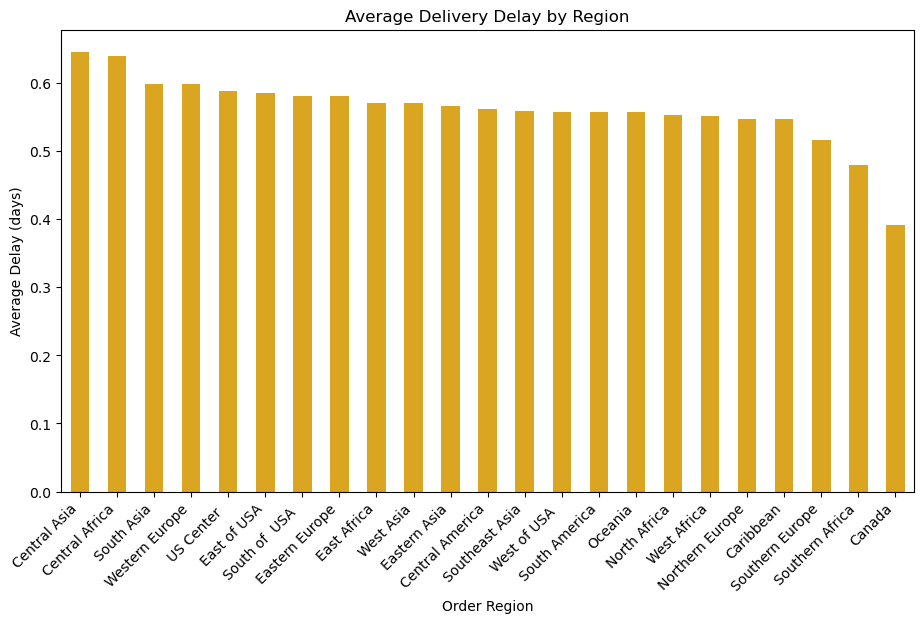

In [54]:
import matplotlib.pyplot as plt

delay_by_region = df.groupby("Order Region")["delay"].mean().sort_values(ascending=False)
delay_by_region.plot(kind="bar", color = 'goldenrod' , figsize=(11,6))
plt.title("Average Delivery Delay by Region")
plt.ylabel("Average Delay (days)")
plt.xticks(rotation = 45, ha = 'right')
plt.show()

In [12]:
correlation = df['Order Item Discount Rate'].corr(df['Order Item Profit Ratio'])
print("Correlation between Discount Rate and Profit Ratio:", correlation)

Correlation between Discount Rate and Profit Ratio: -0.002690810423759878


In [14]:
df['discount_bucket'] = pd.cut(df['Order Item Discount Rate'], bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5], labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%'])
print(df.groupby('discount_bucket', observed = True)['Order Item Profit Ratio'].mean())

discount_bucket
0-10%     0.122042
10-20%    0.118343
20-30%    0.119724
Name: Order Item Profit Ratio, dtype: float64


In [15]:
print(df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False).head(10))

Category Name
Fishing                 756220.767190
Cleats                  494636.919791
Camping & Hiking        427455.568106
Cardio Equipment        383011.098485
Women's Apparel         350421.029567
Water Sports            325146.960038
Indoor/Outdoor Games    318451.430554
Men's Footwear          311902.820214
Shop By Sport           129813.960315
Computers                69656.810171
Name: Order Profit Per Order, dtype: float64


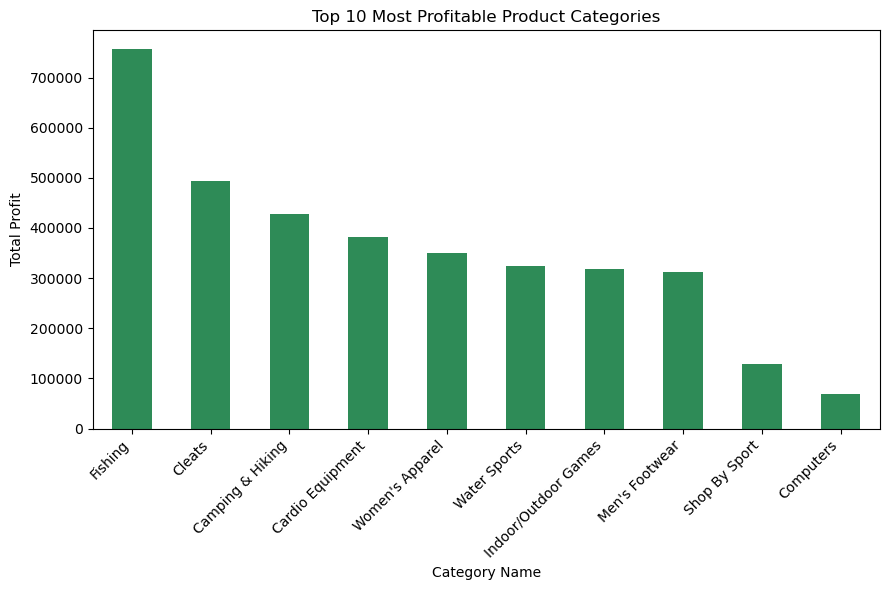

In [30]:
import matplotlib.pyplot as plt

top_categories = df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False).head(10)
top_categories.plot(kind='bar', color='seagreen', figsize=(9,6))
plt.title('Top 10 Most Profitable Product Categories')
plt.ylabel('Total Profit')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

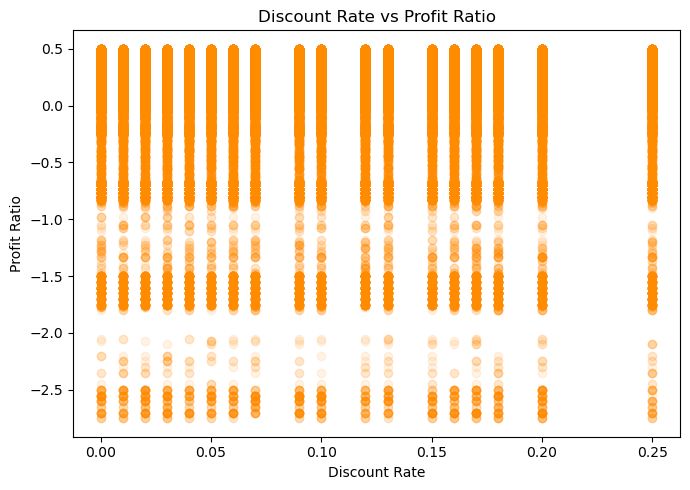

In [36]:
plt.figure(figsize=(7,5))
plt.scatter(df['Order Item Discount Rate'], df['Order Item Profit Ratio'], alpha=0.1, color='darkorange')
plt.title('Discount Rate vs Profit Ratio')
plt.xlabel('Discount Rate')
plt.ylabel('Profit Ratio')
plt.tight_layout()
plt.show()

In [39]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'], format='mixed', dayfirst=False)
print(df['order date (DateOrders)'].head())
print(df['order date (DateOrders)'].dtype)

0   2018-01-31 22:56:00
1   2018-01-13 12:27:00
2   2018-01-13 12:06:00
3   2018-01-13 11:45:00
4   2018-01-13 11:24:00
Name: order date (DateOrders), dtype: datetime64[ns]
datetime64[ns]


In [40]:
snapshot_date = df['order date (DateOrders)'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Order Customer Id').agg({
    'order date (DateOrders)': lambda x: (snapshot_date - x.max()).days,
    'Order Id': 'nunique',
    'Sales per customer': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
print(rfm.head())

                   Recency  Frequency     Monetary
Order Customer Id                                 
1                      793          1   472.450012
2                      137          4  1618.660042
3                      230          5  3189.200037
4                      381          4  1480.709993
5                      458          3  1101.919998


In [41]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

print(rfm.head())

                   Recency  Frequency     Monetary R_score F_score M_score
Order Customer Id                                                         
1                      793          1   472.450012       1       1       2
2                      137          4  1618.660042       3       3       3
3                      230          5  3189.200037       2       3       4
4                      381          4  1480.709993       1       3       3
5                      458          3  1101.919998       1       2       2


In [42]:
rfm['RFM_score'] = rfm['R_score'].astype(int) + rfm['F_score'].astype(int) + rfm['M_score'].astype(int)

def segment(score):
    if score >= 10:
        return 'High Value'
    elif score >= 7:
        return 'Medium Value'
    else:
        return 'Low Value'

rfm['Segment'] = rfm['RFM_score'].apply(segment)

print(rfm['Segment'].value_counts())

Segment
Medium Value    11191
Low Value        6022
High Value       3439
Name: count, dtype: int64


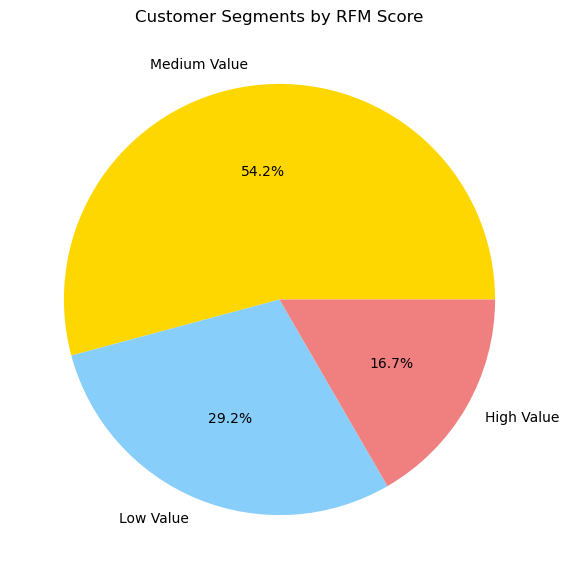

In [43]:
import matplotlib.pyplot as plt

segment_counts = rfm['Segment'].value_counts()
segment_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(7,7), colors=['gold','lightskyblue','lightcoral'])
plt.title('Customer Segments by RFM Score')
plt.ylabel('')
plt.show()